<a href="https://colab.research.google.com/github/awesomesocks123/machinelearning/blob/main/plot_validator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!unzip -q data.zip -d ./extracted_data

In [4]:
!ls ./extracted_data

data


In [5]:
import pandas as pd
import pathlib

In [6]:
data_dir = pathlib.Path('./extracted_data/data')
def load_data(folder_name, label):
    files = list(data_dir.glob(f'{folder_name}/*.csv'))
    df_list = []
    for f in files:
        temp_df = pd.read_csv(f)
        temp_df['label'] = label
        # Add a column for the filename so you can trace back which plot is which
        temp_df['source_file'] = f.name
        df_list.append(temp_df)
    return pd.concat(df_list, ignore_index=True)

# LOAD SEPARATELY
df_train = load_data('good', 1) # Your Golden Set
df_test_outliers = load_data('bad', 0) # Your "Challenge" Set

In [98]:
from sklearn.ensemble import IsolationForest
def get_features(df):

  "flatten the csv into one row of features make it easy for model to digest"
  sig = df['y_signal']
  return {
      'mean': sig.mean(),
      'std': sig.std(),
      'max': sig.max(),
      'min': sig.min(),
      'range': sig.max() - sig.min(),
      'median': sig.median()
  }


  #data prep
def prepare_dataset(folder_path):
  path = pathlib.Path(folder_path)
  feature_list = []
  for f in path.glob('*.csv'):
    df = pd.read_csv(f)
    features = get_features(df)
    feature_list.append(features)
  return pd.DataFrame(feature_list)


#1. load golden set for training
X_train = prepare_dataset('./extracted_data/data/good')

X_test_bad = prepare_dataset('./extracted_data/data/bad')


In [100]:
print(X_train.head())
print(X_test_bad.head())

       mean       std       max       min     range    median
0  1.357982  0.382578  2.363913  0.880404  1.483509  1.266508
1  1.474670  0.486035  2.859584  0.943792  1.915792  1.314125
2  1.404153  0.408824  2.777531  0.940612  1.836919  1.250988
3  1.317760  0.329098  2.199531  0.907270  1.292262  1.203968
4  1.457986  0.462361  2.772273  0.934160  1.838113  1.306956
       mean       std        max       min     range    median
0  6.459882  0.867625   7.994245  5.012191  2.982054  6.454568
1  5.463098  1.972759  12.445452  3.228177  9.217275  5.077355
2  5.059220  1.413583   7.074934  2.939120  4.135814  5.119880
3  5.449650  1.793446  12.110091  3.346954  8.763136  5.041124
4  6.451533  0.861253   8.016662  4.971007  3.045654  6.435819


In [101]:
#contamination refers to the % of the training data that is actually bad and not golden
#set it to very low since we hand picked our golden data
model = IsolationForest(contamination=0.01, random_state=42)
model.fit(X_train)


results = model.predict(X_test_bad)

#score
anomalies_detected = (results == -1).sum()

print(f"Accuracy on Bad Data: {anomalies_detected / len(X_test_bad):.2%}")

Accuracy on Bad Data: 100.00%


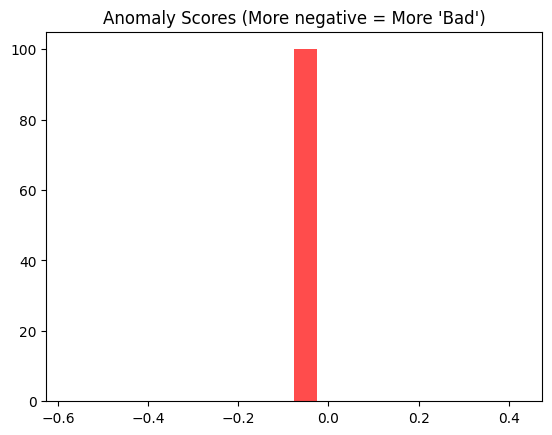

In [103]:

scores = model.decision_function(X_test_bad)


import matplotlib.pyplot as plt
plt.hist(scores, bins=20, color='red', alpha=0.7)
plt.title("Anomaly Scores (More negative = More 'Bad')")
plt.show()